<img src="https://drive.google.com/uc?export=view&id=1WMR33zNEKj_zRZBqyLy4hf_EXhHOAfAk"
     alt="agripotential"
     width="250"
     height="250">
---------------------------------------------------------------------------
* **Author:** Mohammad El Sakka
* **Last Edited:** 23 APR 2026
* **Colab Link:** https://colab.research.google.com/drive/1Ys_z7qBY1pa8iY7PMaLzDsTuiFaJDhHu
* **Version:** 1.0
* **Contact:** mohammad.el-sakka@outlook.com
* **Linkedin:** https://www.linkedin.com/in/mohammad-el-sakka/
* **GitHub:** https://github.com/MohammadElSakka/agripotential

## Citation
If you find this work helpful please cite the following:
```
@inproceedings{el2025agripotential,
  title={AgriPotential: A Novel Multi-Spectral and Multi-Temporal Remote Sensing Dataset for Agricultural Potentials},
  author={El Sakka, Mohammad and De Pourtales, Caroline and Chaari, Lotfi and Mothe, Josiane},
  booktitle={2025 International Conference on Content-Based Multimedia Indexing (CBMI)},
  pages={1--6},
  year={2025},
  organization={IEEE}
}
```
---------------------------------------------------------------------------

******** Notice ********

This notebook is in view only mode. We suggest to make your own copy that you can execute and edit.

To do so click on ```File > Save a copy in Drive``` or ```File > Download > Download .ipynb```


# Table of Contents
(Colab-style)


>[AgriPotential (v2)](#scrollTo=nwZJYNb379jY)

>>[Dataset structure](#scrollTo=7YdCq3SOBFcc)

>>[Accessing the data](#scrollTo=St3V3q6UCm48)

>>>[The metadata](#scrollTo=mWbj9R32FN2l)

>>>[Patch metadata](#scrollTo=KKT4Xfqocgx6)

>>>[Sentinel-2](#scrollTo=S6ySv5chA3Am)

>>>[Agricultural Potential Labels](#scrollTo=QolGydDaZfuc)

>>[Torch Dataset object](#scrollTo=Mz6bWkvLerYW)

>>[Using the AgriPotential Library](#scrollTo=TrtEUyNaevia)



# AgriPotential (v2)
Welcome to the AgriPotential tutorial which will show you how to easily access and manipulate the AgriPotential dataset.

To recall, the Agripotential dataset includes:
* As **inputs**: a Satellite Image Time Series (STIS) of 34 Sentinel-2 timeframes
* As **outputs**: 5 classes of agriculutural potential of 3 crops times, namely: very low, low, average, high, very high


Each Sentinel-2 image is made of 10 super-resolved bands at 5 m/px resolution, meaning that each pixel in the image measures 5 meters in realiy. A quick guide on Sentinel-2 images can be found at the [gisgeography](https://gisgeography.com/sentinel-2-bands-combinations/ ) website. Among the 13 original Sentinel-2 bands, the agripotential dataset has bands B2 B3 B4 B5 B6 B7 B8 B8A B11 B12.


## Dataset structure
The dataset is hosted on [HuggingFace](https://huggingface.co/datasets/m-sakka/agripotential/tree/main)

It contains:
* 34 TIF files corresponding to the 34 timeframes of Sentinel-2 images.
* 3 TIF files corresponding to the 3 crop types
* 3 CSV files with patch information
* 1 CSV file for metadata

The dataset has a zize of 200 GB. Files can be downloaded separately or together from HuggingFace. They can also be accessed **online** without the need of downloading them (if connection is too slow or if the server has a problem, online dataloading could be interrupted and raise an error)



## Accessing the data


### The metadata

The metadata file can be loaded using the standard csv library of Python but we prefer using pandas as it can load it from a remote server as well

Pandas can be install via
```
pip install pandas
```

The metadata contains the file names of Sentinel-2 data, ordered by ascending capture date. Notice how all file names start with T31TEJ. This is the name of the Sentinel-2 tile that covers the study area. A deeper explanation of Sentinel-2 tiles is presented on the [Copernicus Wiki website](https://sentiwiki.copernicus.eu/web/s2-products)

In [ ]:
import pandas as pd

# root_path: The directory where the dataset is downloaded or hosted.
root_path = "https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/"
path = root_path + "metadata.csv"
metadata = pd.read_csv(path)
metadata.head()

,filename,day,month,year
0,T31TEJ_2017_01_03.tif,3,1,2017
1,T31TEJ_2017_03_29.tif,29,3,2017
2,T31TEJ_2017_06_17.tif,17,6,2017
3,T31TEJ_2017_07_07.tif,7,7,2017
4,T31TEJ_2017_07_17.tif,17,7,2017


### Patch metadata
Given the voluminous aspect of the data, saving each patch as a separate file raises challenges in terms of storage and access. For this reason, only the coordinates of the patches are saved inside 3 csv files. Each csv file represents a subset of "train", "test", and "val".

The strucutre of the 3 csv files is identical. The columns are patch_id, the coordinates in row and col, the patch_size, and n_annoted that shows the number of annotated pixels in the patch

In [ ]:
train_subset_path = root_path + "train.csv"

train_df = pd.read_csv(train_subset_path)
train_df.head()

,patch_id,row,col,patch_size,n_annotated
0,7296_14720,7296,14720,128,1724
1,5120_12672,5120,12672,128,4575
2,5184_12608,5184,12608,128,863
3,5184_12672,5184,12672,128,4077
4,5248_12608,5248,12608,128,1324


### Sentinel-2

Loading TIF files can be done via rasterio. Rasterio will create a pointer towards the data instead of loading it entirely and immediately in the memory. Another advantage of Rasterio is the possibility it offers to load the data from a remote server over http requests (like HuggingFace).

Rasterio can be installed by
```
pip install rasterio
```

As an example, we will display the first train patch during three different dates. With Rasterio, it is possible to load a Window of the bigger TIF image (very voluminous!).

In [ ]:
from rasterio import rasterio
from rasterio.windows import Window

patch_row = train_df.iloc[0]["row"]
patch_col = train_df.iloc[0]["col"]
patch_size = train_df.iloc[0]["patch_size"]
patch_id = train_df.iloc[0]["patch_id"]

date1 = metadata.iloc[0]
date2 = metadata.iloc[15]
date3 = metadata.iloc[30]

print(date1)
print("--------------")
print(date2)
print("--------------")
print(date3)

filename    T31TEJ_2017_01_03.tif
day                             3
month                           1
year                         2017
Name: 0, dtype: object
--------------
filename    T31TEJ_2018_06_27.tif
day                            27
month                           6
year                         2018
Name: 15, dtype: object
--------------
filename    T31TEJ_2019_08_31.tif
day                            31
month                           8
year                         2019
Name: 30, dtype: object


In [ ]:
date1_data = rasterio.open(root_path+date1["filename"])
date2_data = rasterio.open(root_path+date2["filename"])
date3_data = rasterio.open(root_path+date3["filename"])

date1_data.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -10000.0,
 'width': 18770,
 'height': 15286,
 'count': 10,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'),
 'transform': Affine(5.0, 0.0, 500140.0,
        0.0, -5.0, 4866810.0)}

A single Sentinel-2 timeframe contains 10 bands as previously stated. In a first time we will display some of them for illustration purpose, then we will reconstruct a color (RGB) image from the red, green, and blue bands (resp. B4, B3, B2)

In [ ]:
date1_image = date1_data.read(window=Window(patch_col, patch_row, patch_size, patch_size))
date2_image = date2_data.read(window=Window(patch_col, patch_row, patch_size, patch_size))
date3_image = date3_data.read(window=Window(patch_col, patch_row, patch_size, patch_size))

date1_image.shape

(10, 128, 128)

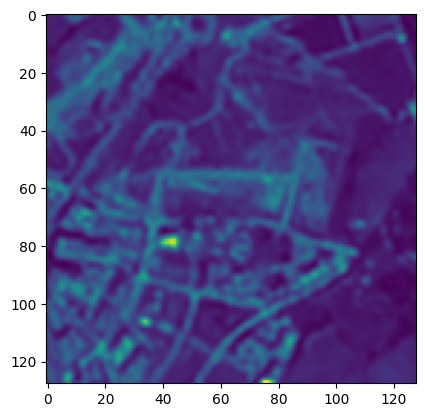

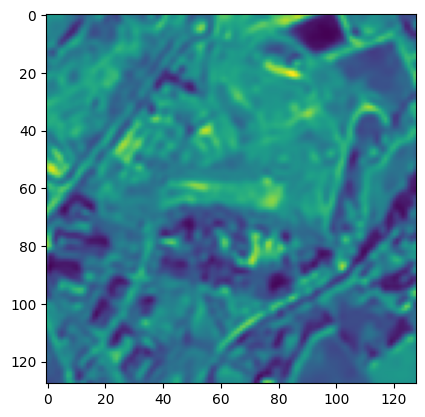

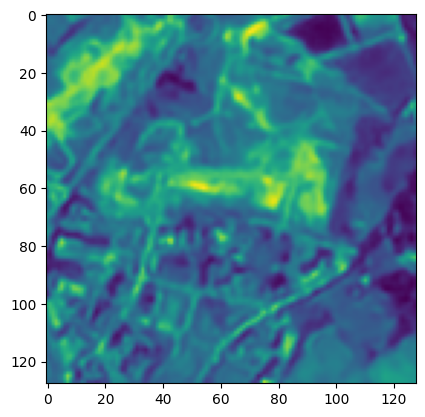

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(date1_image[0])
plt.show()
plt.imshow(date1_image[5])
plt.show()
plt.imshow(date1_image[9])
plt.show()

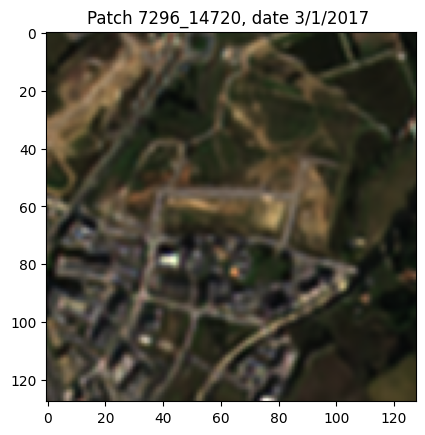

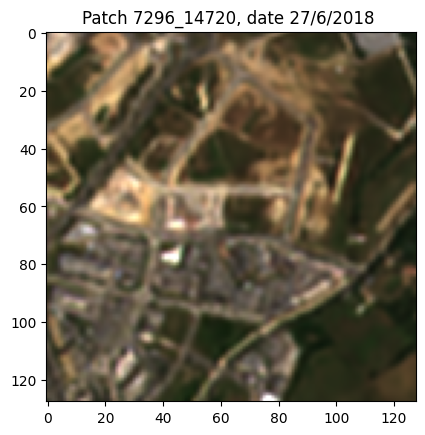

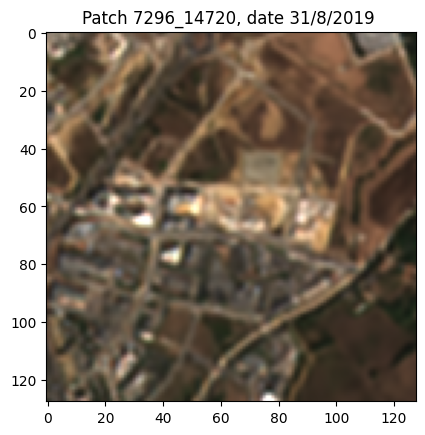

In [ ]:
import numpy as np

def plot_rgb(red_band, green_band, blue_band, title):
  rgb = np.dstack((red_band, green_band, blue_band))

  # Sentinel-2 images provide reflectance in values between 0 and 10000.
  # Normalization
  rgb = rgb / 10000

  # Applying contrast enhancement for visualization
  rgb = np.clip(rgb, 0, 0.4)/ 0.4

  plt.imshow(rgb)
  plt.title(title)
  plt.show()

red1 = date1_image[2]
green1 = date1_image[1]
blue1 = date1_image[0]

red2 = date2_image[2]
green2 = date2_image[1]
blue2 = date2_image[0]

red3 = date3_image[2]
green3 = date3_image[1]
blue3 = date3_image[0]

plot_rgb(red1, green1, blue1, title=f"Patch {patch_id}, date {date1["day"]}/{date1["month"]}/{date1["year"]} ")
plot_rgb(red2, green2, blue2, title=f"Patch {patch_id}, date {date2["day"]}/{date2["month"]}/{date2["year"]} ")
plot_rgb(red3, green3, blue3, title=f"Patch {patch_id}, date {date3["day"]}/{date3["month"]}/{date3["year"]} ")

### Agricultural Potential Labels
Each crop type has a corresponding TIF file for its labels. Those TIF files are aligned with the Sentinel-2 images. Therefore, loading labels is similar to loading Sentinel-2 images in our dataset.

We will work with the "viticulture" crop type for this example.

In [ ]:
viticulture_label_path = root_path + "viticulture.tif"
viticulture_label_data = rasterio.open(viticulture_label_path)
viticulture_label_data.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 18770,
 'height': 15286,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'),
 'transform': Affine(5.0, 0.0, 500140.0,
        0.0, -5.0, 4866810.0)}

In [ ]:
viticulture_sample = viticulture_label_data.read(window=Window(patch_col, patch_row, patch_size, patch_size))
print(viticulture_sample.shape)
print(np.unique(viticulture_sample))

(1, 128, 128)
[0 2 3]


As you can see, some label pixels are set to 0. Those are pixels that are unlabelled and should not affect training. Otherwise, labelled pixels have a range of [1, 5], respectively corresponding to: "very low", "low", "average", "high", "very high"

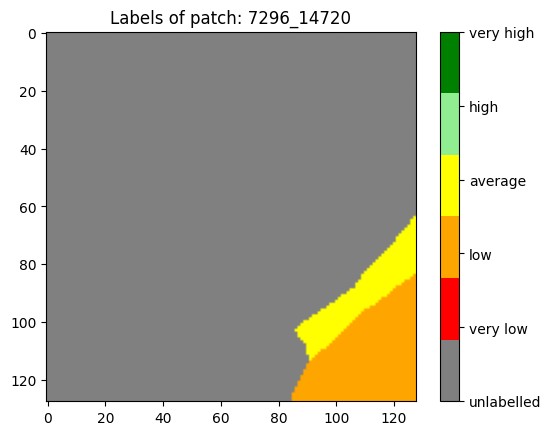

In [ ]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

colors = [
    "gray",
    "red",
    "orange",
    "yellow",
    "#90EE90",  # Hex code for light green
    "green"
]

cmap = LinearSegmentedColormap.from_list(
    "Custom_GrayRedGreen",
    colors,
    N=6
)

plt.imshow(viticulture_sample[0], vmin=0, vmax=5, cmap=cmap)
cbar = plt.colorbar(ticks=[0, 1, 2, 3, 4, 5])
cbar.set_ticklabels(["unlabelled", "very low", "low", "average", "high", "very high"])
plt.title("Labels of patch: "+patch_id)
plt.show()

## Torch Dataset object

For illustration, we provide a torch Dataset object


In [ ]:
import os
from torch.utils.data import Dataset

import os
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import rasterio
from rasterio.windows import Window

class PotentialDataset(Dataset):
  """
  A PyTorch Dataset class for loading AgriPotential image patches
  and corresponding crop type labels, organized based on patch metadata.

  The dataset expects a root directory structure containing:
  - 'metadata.csv': A file listing Sentinel-2 file paths.
  - '{subset}.csv': A file defining the patch coordinates (row, col, patch_size)
                    for the specific subset (e.g., 'train', 'val', 'test').
  - '{crop_type}.tif': A GeoTIFF file containing the ground truth crop type
                       labels.
  - 34 Sentinel-2 GeoTIFF files referenced in 'metadata.csv'.

  Attributes:
    root_url (str): The root directory containing the data files.
                    For online loading use https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/
    crop_type (str): Identifier for the label GeoTIFF file (e.g., 'crop_labels').
    subset (str): Identifier for the patch definition CSV file (e.g., 'train').
    metadata_df (pd.DataFrame): DataFrame loaded from 'metadata.csv' containing
                                Sentinel-2 file information.
    patch_df (pd.DataFrame): DataFrame loaded from '{subset}.csv' containing
                             patch details (row, col, patch_size).
    label_path (str): Full path to the crop type label GeoTIFF file.
    sentinel2_paths (list): List of full paths to the Sentinel-2 GeoTIFF files.
  """
  def __init__(self, root_url, crop_type, subset):
    """
    Initializes the dataset

    Args:
      root_url (str): The base directory path for the dataset.
      crop_type (str): The name of the label file (e.g., "viticulture", "market", "field")
      subset (str): The name of the subset (e.g., "train", "val", "test")
    """
    super().__init__()
    self.root_url = root_url
    self.subset = subset

    # Load metadata and patch information
    self.metadata_df = pd.read_csv(self.root_url + "metadata.csv")
    self.patch_df = pd.read_csv(self.root_url + subset +".csv")

    # Define paths
    self.label_path = self.root_url + crop_type + ".tif"
    self.sentinel2_paths = []
    for f in self.metadata_df["filename"]:
      self.sentinel2_paths.append(os.path.join(self.root_url, f))

  def __len__(self):
    """
    Returns the total number of patches in the dataset subset.

    Returns:
      int: The number of rows in self.patch_df.
    """
    return len(self.patch_df)

  def __getitem__(self, idx):
    """
    Retrieves the Sentinel-2 data, corresponding label, and patch ID for a given index.

    The Sentinel-2 data is stacked across the time dimension (i.e., multiple GeoTIFFs),
    and then the bands from each image are implicitly stacked resulting in a
    shape of (34 Timeframes, 10 Bands, PatchSize, PatchSize)

    Args:
      idx (int): The index of the patch to retrieve (from 0 to len-1).

    Returns:
      tuple: A tuple containing:
        - data (np.ndarray): The stacked Sentinel-2 patch data. Shape: (34, 10, P, P) where P is patch_size.
        - label (np.ndarray): The corresponding crop type label patch. Shape: (P, P).
        - patch_id (int or str): The unique identifier for the patch.
    """
    patch = self.patch_df.iloc[idx]
    patch_row = patch["row"]
    patch_col = patch["col"]
    patch_size = patch["patch_size"]
    patch_id = patch["patch_id"]

    data = np.empty((34, 10, patch_size, patch_size), dtype=np.float32)
    window = Window(patch_col, patch_row, patch_size, patch_size)
    for i, fp in enumerate(self.sentinel2_paths):
      with rasterio.open(fp) as src:
        data[i] = src.read(window=window)

    label = rasterio.open(self.label_path).read(window=window)[0]

    return data, label, patch_id

In [ ]:
from torch.utils.data import DataLoader

dataset = PotentialDataset(root_path, "viticulture", "val")
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
iterator = iter(dataloader)

print(root_path)


https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/


In [ ]:
data_batch, label_batch, patch_id_batch = next(iterator)
print(data_batch.shape)
print(label_batch.shape)
print(patch_id_batch)

torch.Size([4, 34, 10, 128, 128])
torch.Size([4, 128, 128])
('9472_2048', '9472_2112', '9472_2176', '9536_2048')


## Using the AgriPotential Library
You can achieve the same behavior with the AgriPotential library that contains utilities related to the AgriPotential dataset

In [ ]:
# If a pip error (below) occurs, it is normal in Colab and will not affect the tutorial
# ----
# ERROR: pip's dependency resolver does not currently take into account all the packages that are installed.
# This behaviour is the source of the following dependency conflicts.
# google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
# ----
!pip install git+https://github.com/MohammadElSakka/agripotential.git

  Cloning https://github.com/MohammadElSakka/agripotential.git to /tmp/pip-req-build-r2ivenrl
  Running command git clone --filter=blob:none --quiet https://github.com/MohammadElSakka/agripotential.git /tmp/pip-req-build-r2ivenrl
  Resolved https://github.com/MohammadElSakka/agripotential.git to commit 634955a8a9a78efdd5213d77a1cdd9372c0f7d7a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# should be ok if no error message
import agripotential

In [ ]:
from agripotential.dataset import download_dataset

#   dest_dir (str): The destination directory where the dataset will be downloaded.
#   download_images (bool): Whether to download the Sentinel-2 image files. Defaults to True.
#                            can take some time
data_path = "./data/"
download_dataset(data_path, download_images=False)


[1/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/train.csv... Done.
[2/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/val.csv... Done.
[3/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/metadata.csv... Done.
[1/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/viticulture.tif... Done.
[2/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/market.tif... Done.
[3/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/field.tif... Done.


True

In [ ]:
from agripotential.dataset import PotentialDataset
# This is a vanilla python dataset object that is compatible with PyTorch DataLoader

# if data_path is None, the class will retrieve the dataset online,
# otherwise it expects a directory with all the dataset material
# label_name is one of the three crop types: viticulture, market, field
# subset is one of train test val
dataset = PotentialDataset(data_path=None, label_name="viticulture", mode="val")


If the following cell crashes it is more likely an issue with the environment or the network on Colab.

Expected output:
```
torch.Size([4, 34, 10, 128, 128])
torch.Size([4, 128, 128])
('9472_2048', '9472_2112', '9472_2176', '9536_2048')
```

In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
iterator = iter(dataloader)

data_batch, label_batch, patch_id_batch = next(iterator)
print(data_batch.shape)
print(label_batch.shape)
print(patch_id_batch)

torch.Size([4, 34, 10, 128, 128])
torch.Size([4, 128, 128])
('9472_2048', '9472_2112', '9472_2176', '9536_2048')
